# Evaluate Saved Checkpoint
Reload trained model (and optional temperature scaler) to score val/test and plot reliability.


In [14]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [15]:
# Choose device manually ("cpu" or "cuda"); set to None to auto-detect
DEVICE_OVERRIDE = None  # e.g., "cpu" to force CPU, "cuda" to force GPU if available

In [16]:
from pathlib import Path
import json

RUNS_ROOT = Path('../training_runs')
RUNS_ROOT.mkdir(exist_ok=True)

# Set to a specific experiment folder name to override selection
SELECTED_EXPERIMENT = None  # e.g., 'experiment_resnet18_20240520-1530'

exp_dirs = [p for p in RUNS_ROOT.iterdir() if p.is_dir()]
if not exp_dirs:
    raise FileNotFoundError(f'No experiments found under {RUNS_ROOT}')
if SELECTED_EXPERIMENT:
    RUN_DIR = RUNS_ROOT / SELECTED_EXPERIMENT
else:
    RUN_DIR = max(exp_dirs, key=lambda p: p.stat().st_mtime)

PLOTS_DIR = RUN_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR = RUN_DIR / 'artifacts'
CONFIG_PATH = RUN_DIR / 'config.json'
print(f'Using experiment: {RUN_DIR.name}')

Using experiment: resnet18_original_dataset


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot theming
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.dpi': 300, 'savefig.dpi': 300, 'axes.titlesize': 12, 'axes.labelsize': 11, 'legend.fontsize': 10})

def save_fig(fig, name: str, prefix: str = 'eval'):
    path = PLOTS_DIR / f'{prefix}_{name}.pdf'
    fig.savefig(path, bbox_inches='tight', format='pdf')
    print(f'Saved figure to {path}')
    return path


In [18]:
from utils import load_checkpoint
from training import Trainer
from validation import evaluate, reliability_bins, TemperatureScaler
from config import build_config_from_dict

ckpt_path = ARTIFACTS_DIR / 'checkpoints/best.pt'
model, cfg = load_checkpoint(str(ckpt_path))

# Prefer config file on disk to keep paths consistent
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        cfg = build_config_from_dict(json.load(f))

if DEVICE_OVERRIDE:
    cfg.device_override = DEVICE_OVERRIDE

trainer = Trainer(cfg)
trainer.model = model.to(trainer.device)

temp_path = Path(cfg.checkpoints_dir) / "temperature.pt"
temperature = TemperatureScaler.load(temp_path, device=trainer.device) if temp_path.exists() else None

In [19]:
val_metrics, val_outputs = evaluate(
    trainer.model,
    trainer.val_loader,
    trainer.device,
    trainer.cfg,
    temperature=temperature,
)
test_metrics, test_outputs = evaluate(
    trainer.model,
    trainer.test_loader,
    trainer.device,
    trainer.cfg,
    temperature=temperature,
)

with open(RUN_DIR / "eval_metrics.json", "w") as f:
    json.dump({"val": val_metrics, "test": test_metrics}, f, indent=2)
print(f"Saved eval metrics to {RUN_DIR / 'eval_metrics.json'}")
val_metrics, test_metrics


Saved eval metrics to ../training_runs/resnet18_original_dataset/eval_metrics.json


({'accuracy': 0.9755,
  'macro_precision': 0.9763006614118332,
  'macro_recall': 0.9755,
  'macro_f1': 0.9754896995462343,
  'brier': 0.016957671565404092,
  'ece': 0.017297426998615285},
 {'accuracy': 0.9725,
  'macro_precision': 0.973458753976803,
  'macro_recall': 0.9724999999999999,
  'macro_f1': 0.972486071073481,
  'brier': 0.02002637874887904,
  'ece': 0.013759899407625223})

Saved figure to ../training_runs/resnet18_original_dataset/plots/evaluate_reliability_val.pdf


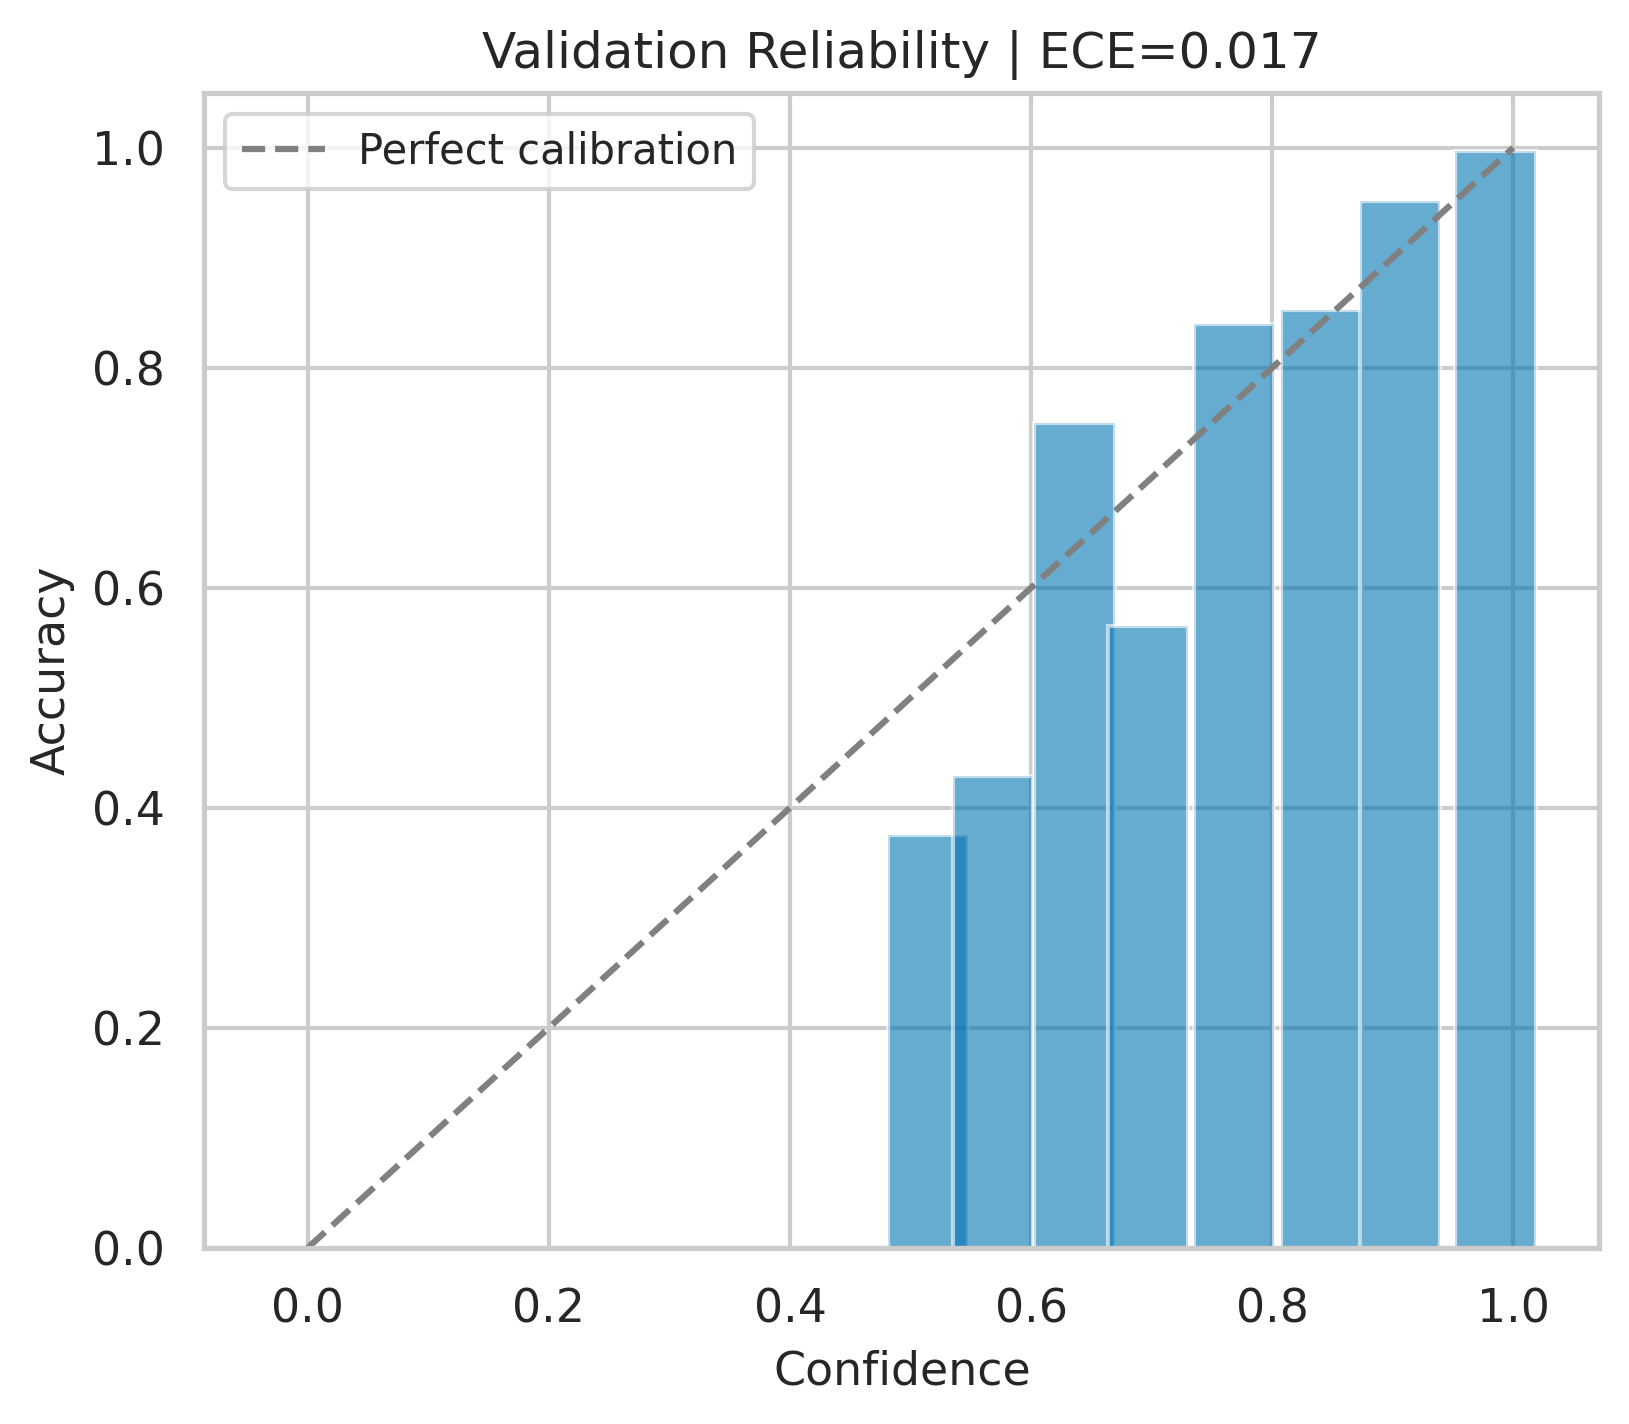

Saved figure to ../training_runs/resnet18_original_dataset/plots/evaluate_reliability_test.pdf


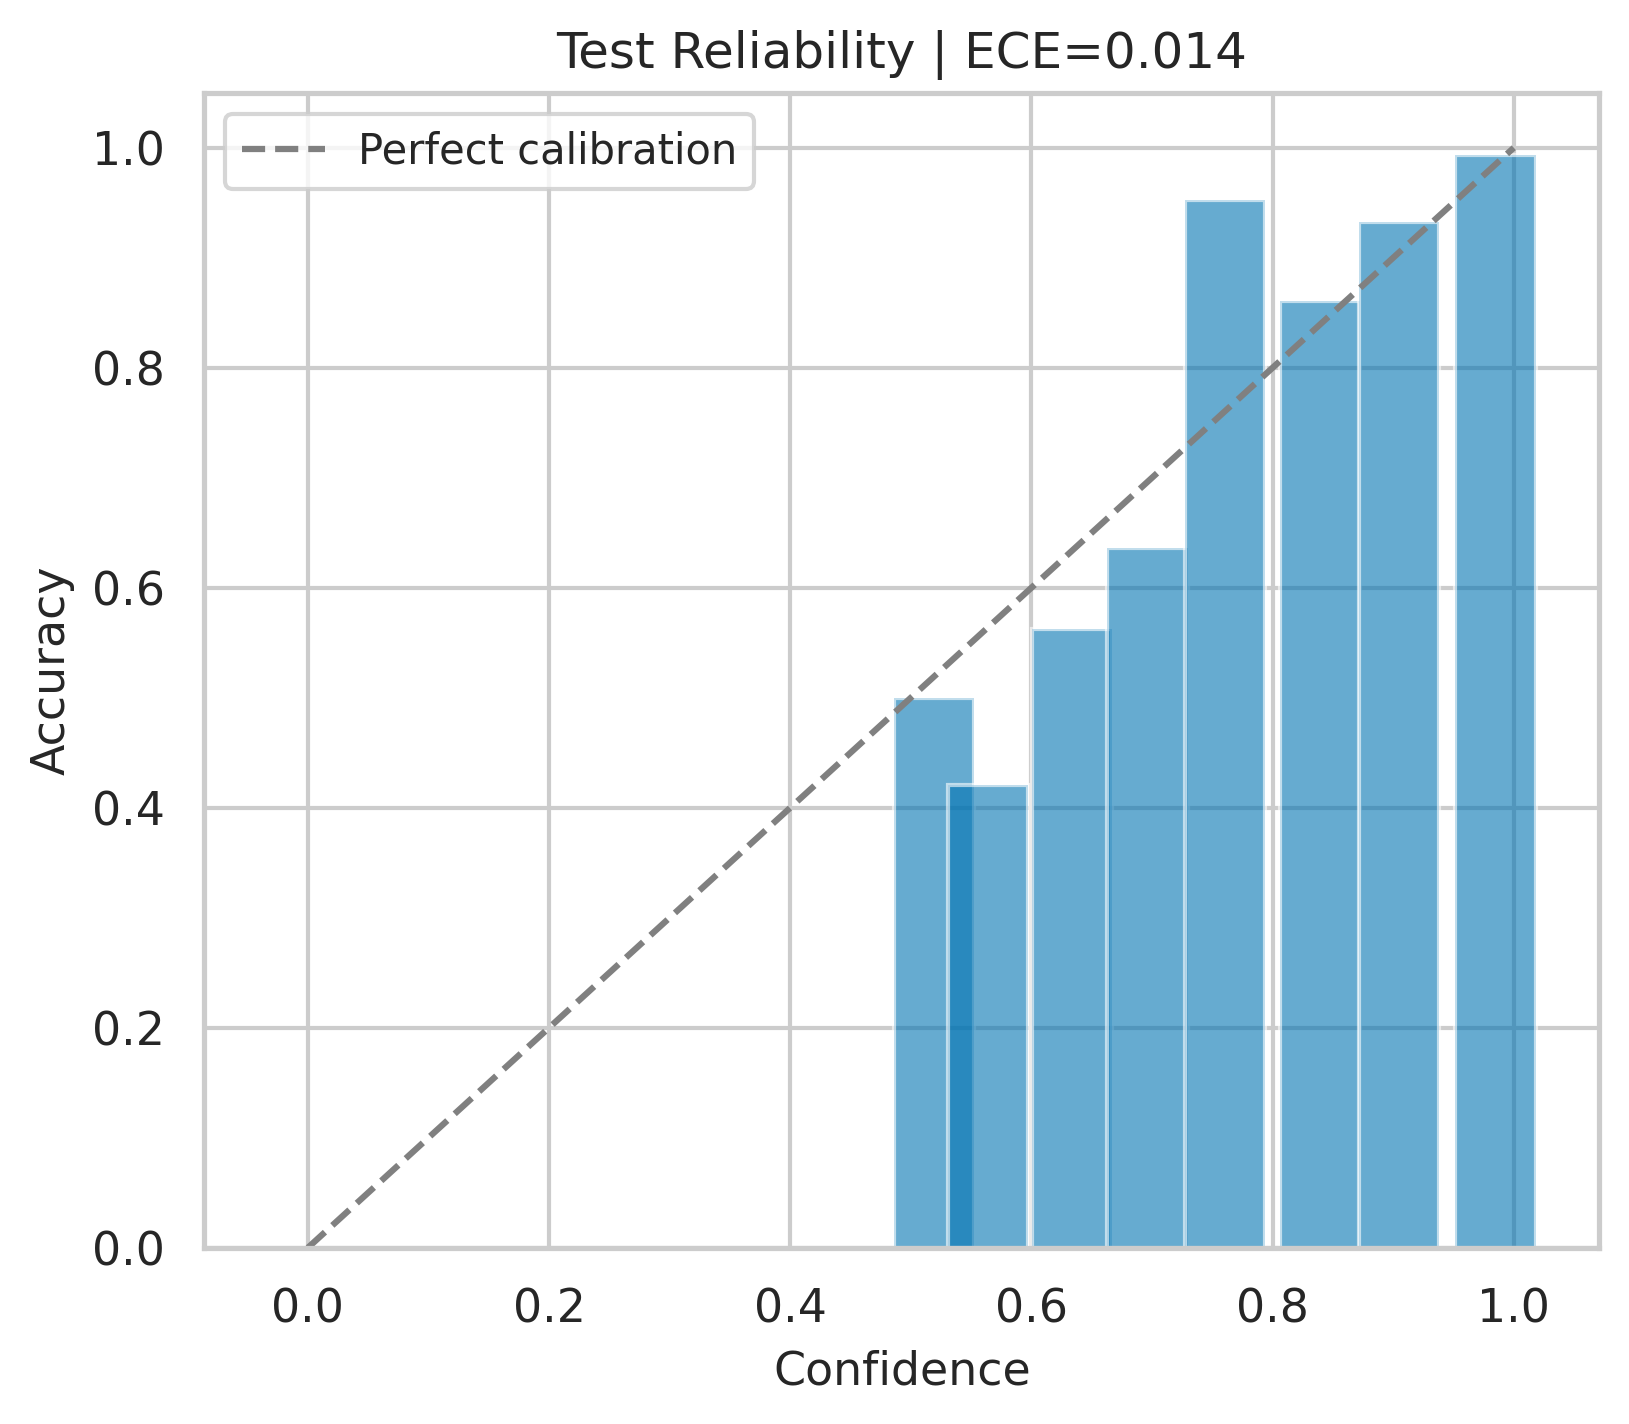

Saved figure to ../training_runs/resnet18_original_dataset/plots/evaluate_confusion_val.pdf


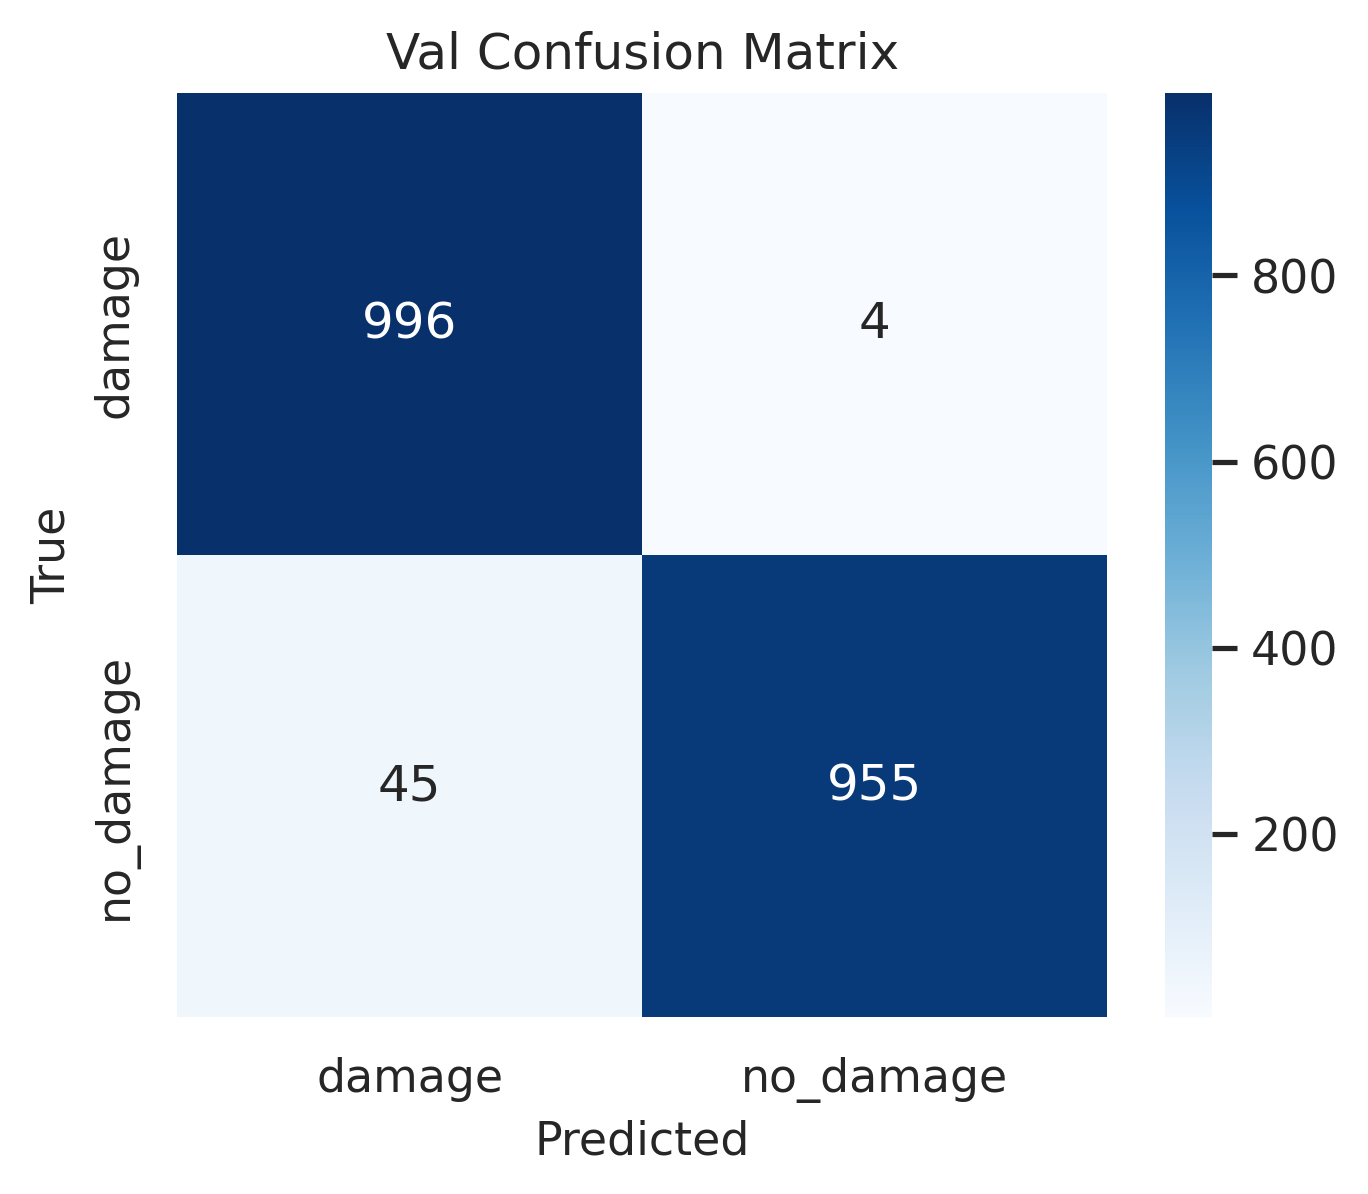

Saved figure to ../training_runs/resnet18_original_dataset/plots/evaluate_confusion_test.pdf


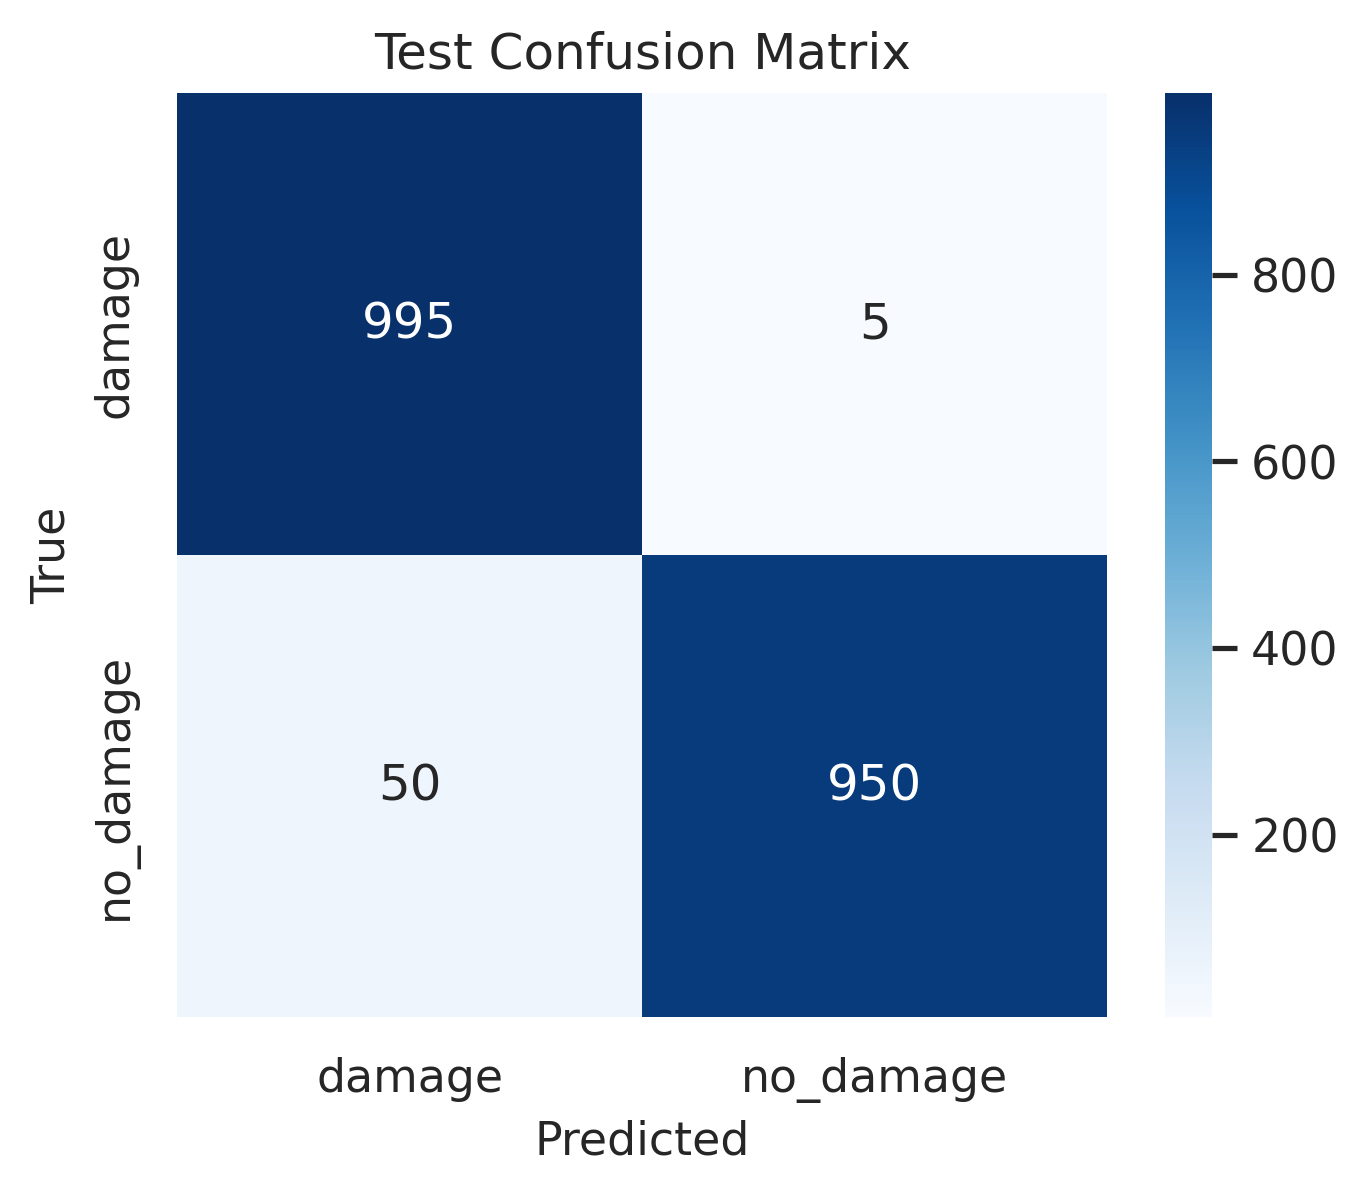

Saved figure to ../training_runs/resnet18_original_dataset/plots/evaluate_score_hist_val.pdf


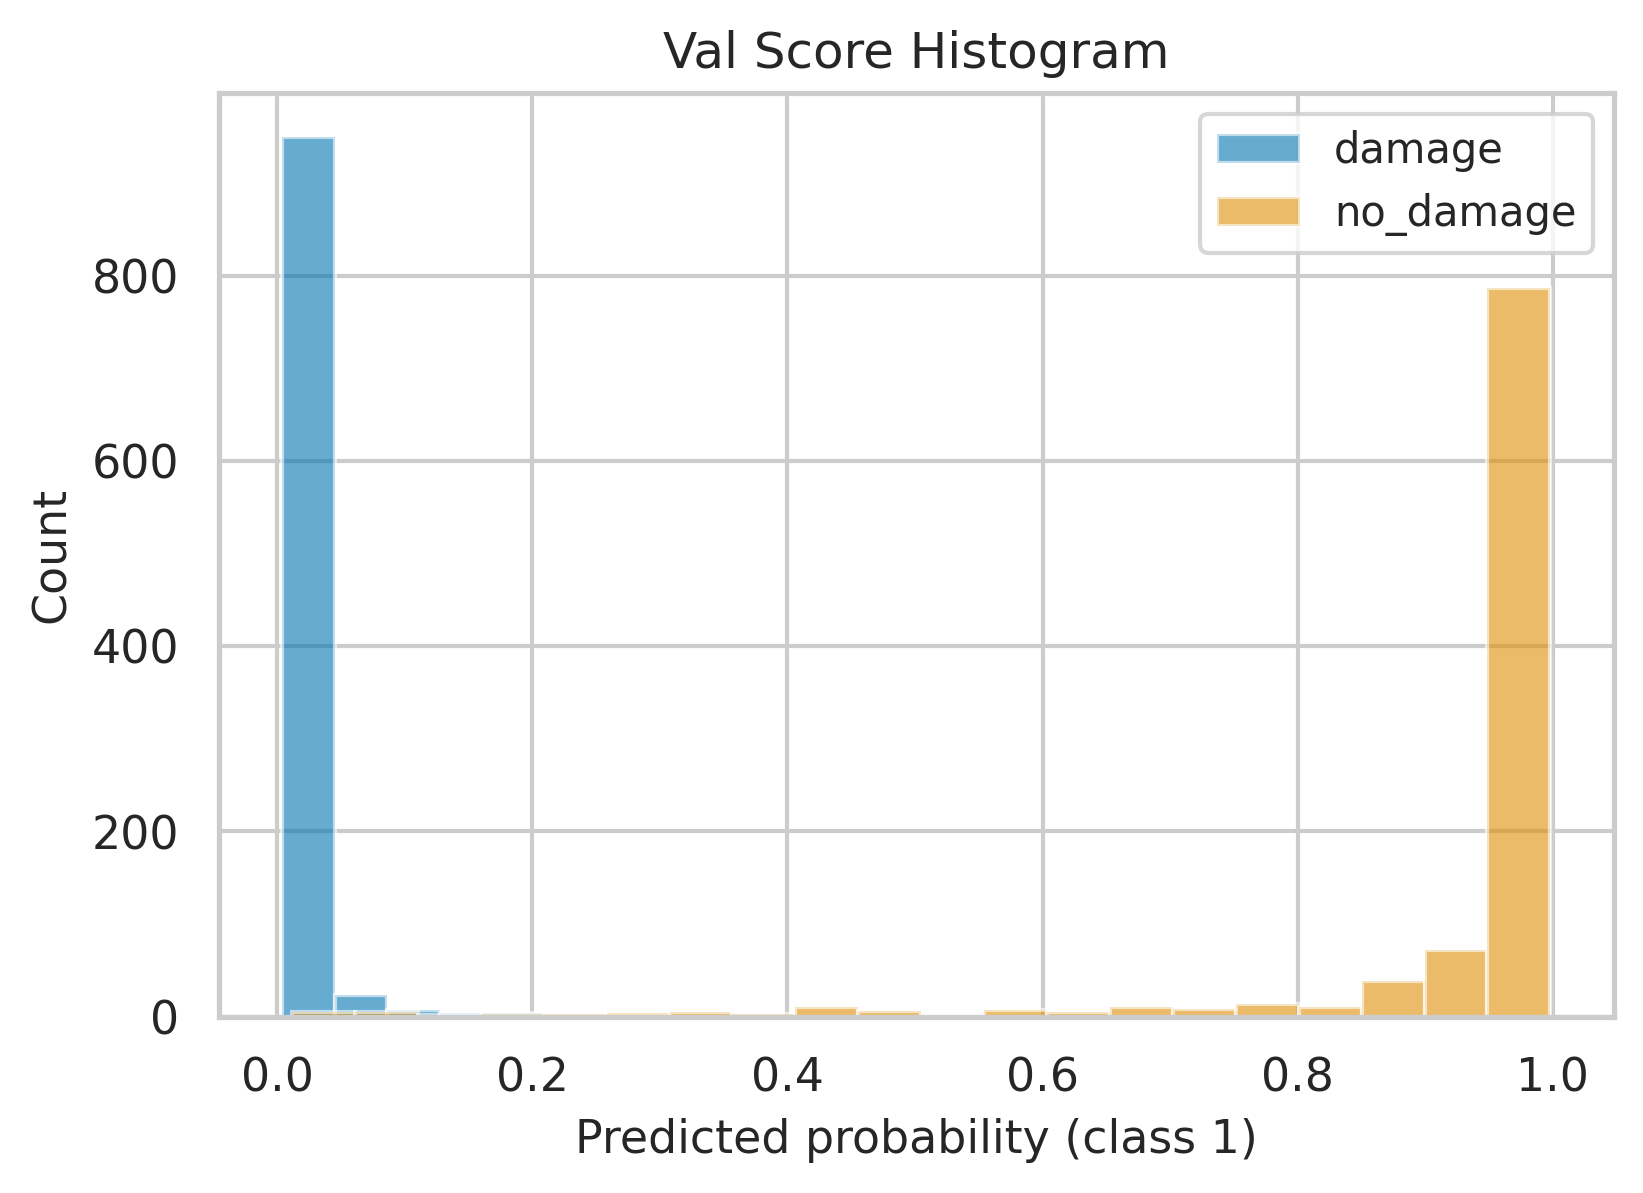

Saved figure to ../training_runs/resnet18_original_dataset/plots/evaluate_score_hist_test.pdf


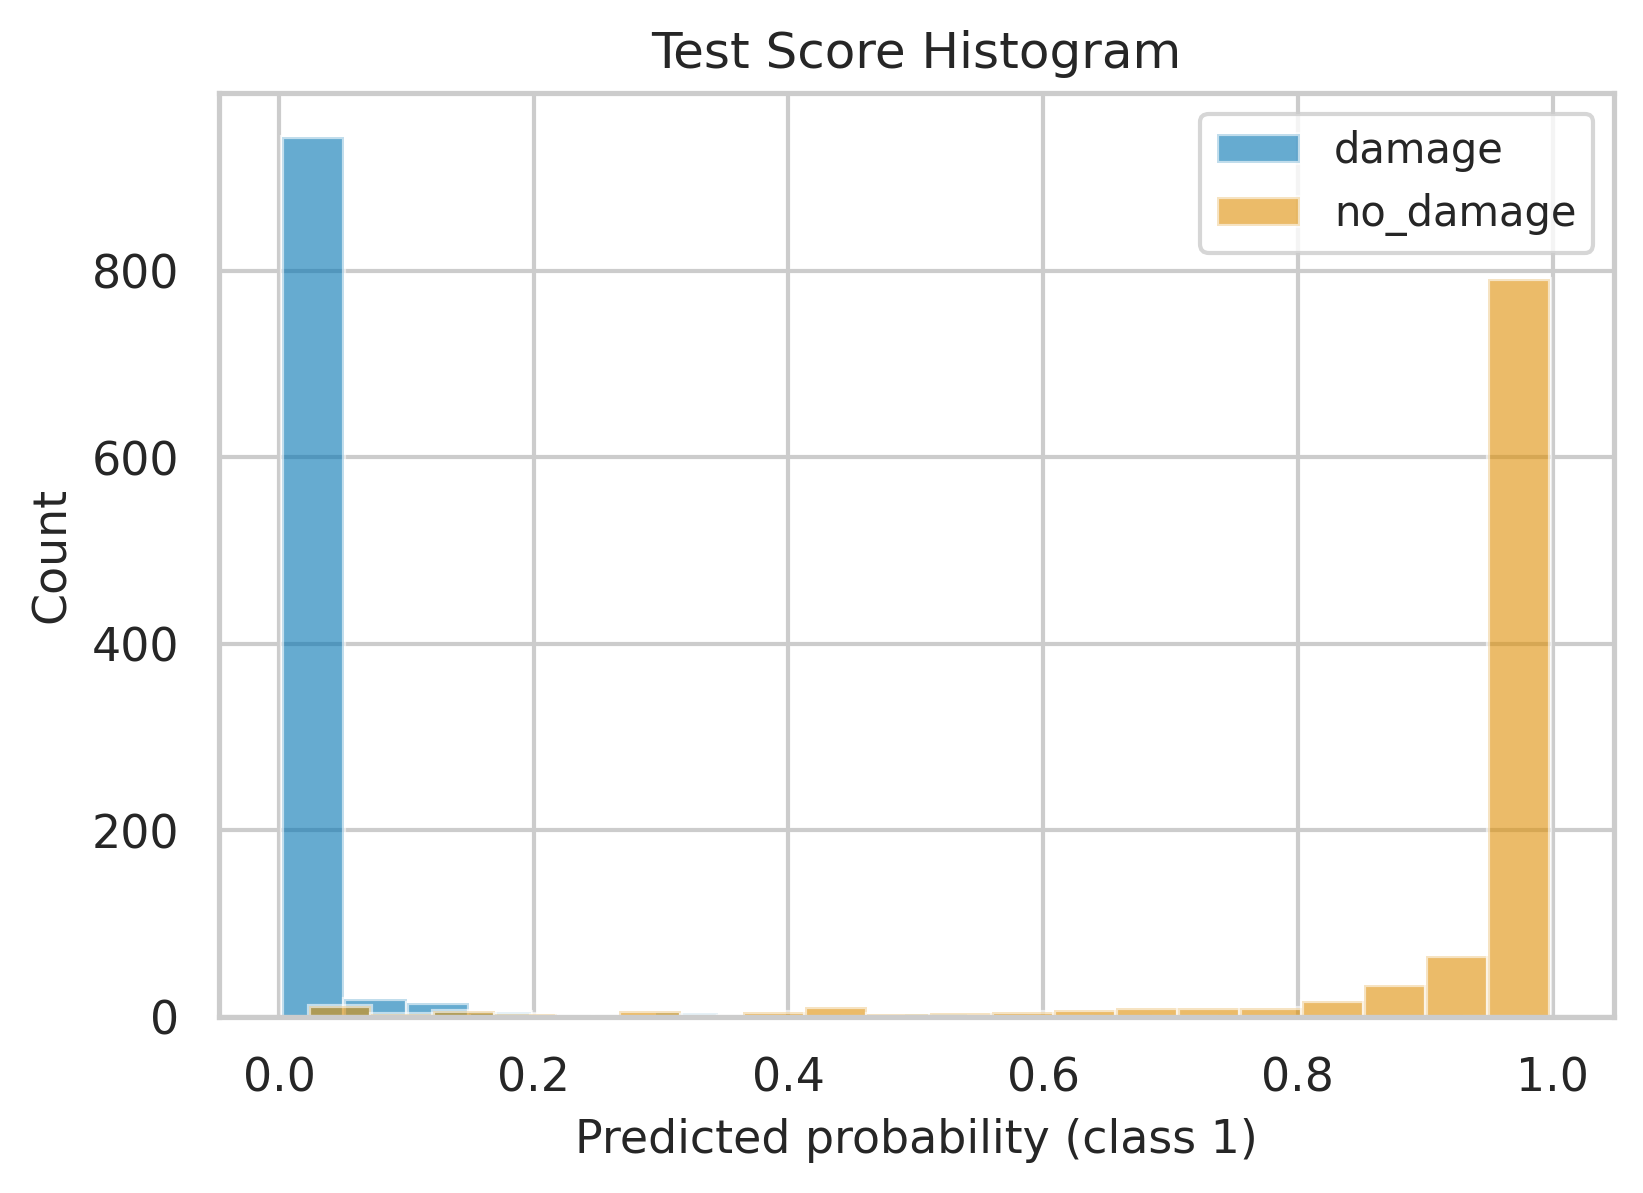

Saved figure to ../training_runs/resnet18_original_dataset/plots/evaluate_metrics.pdf


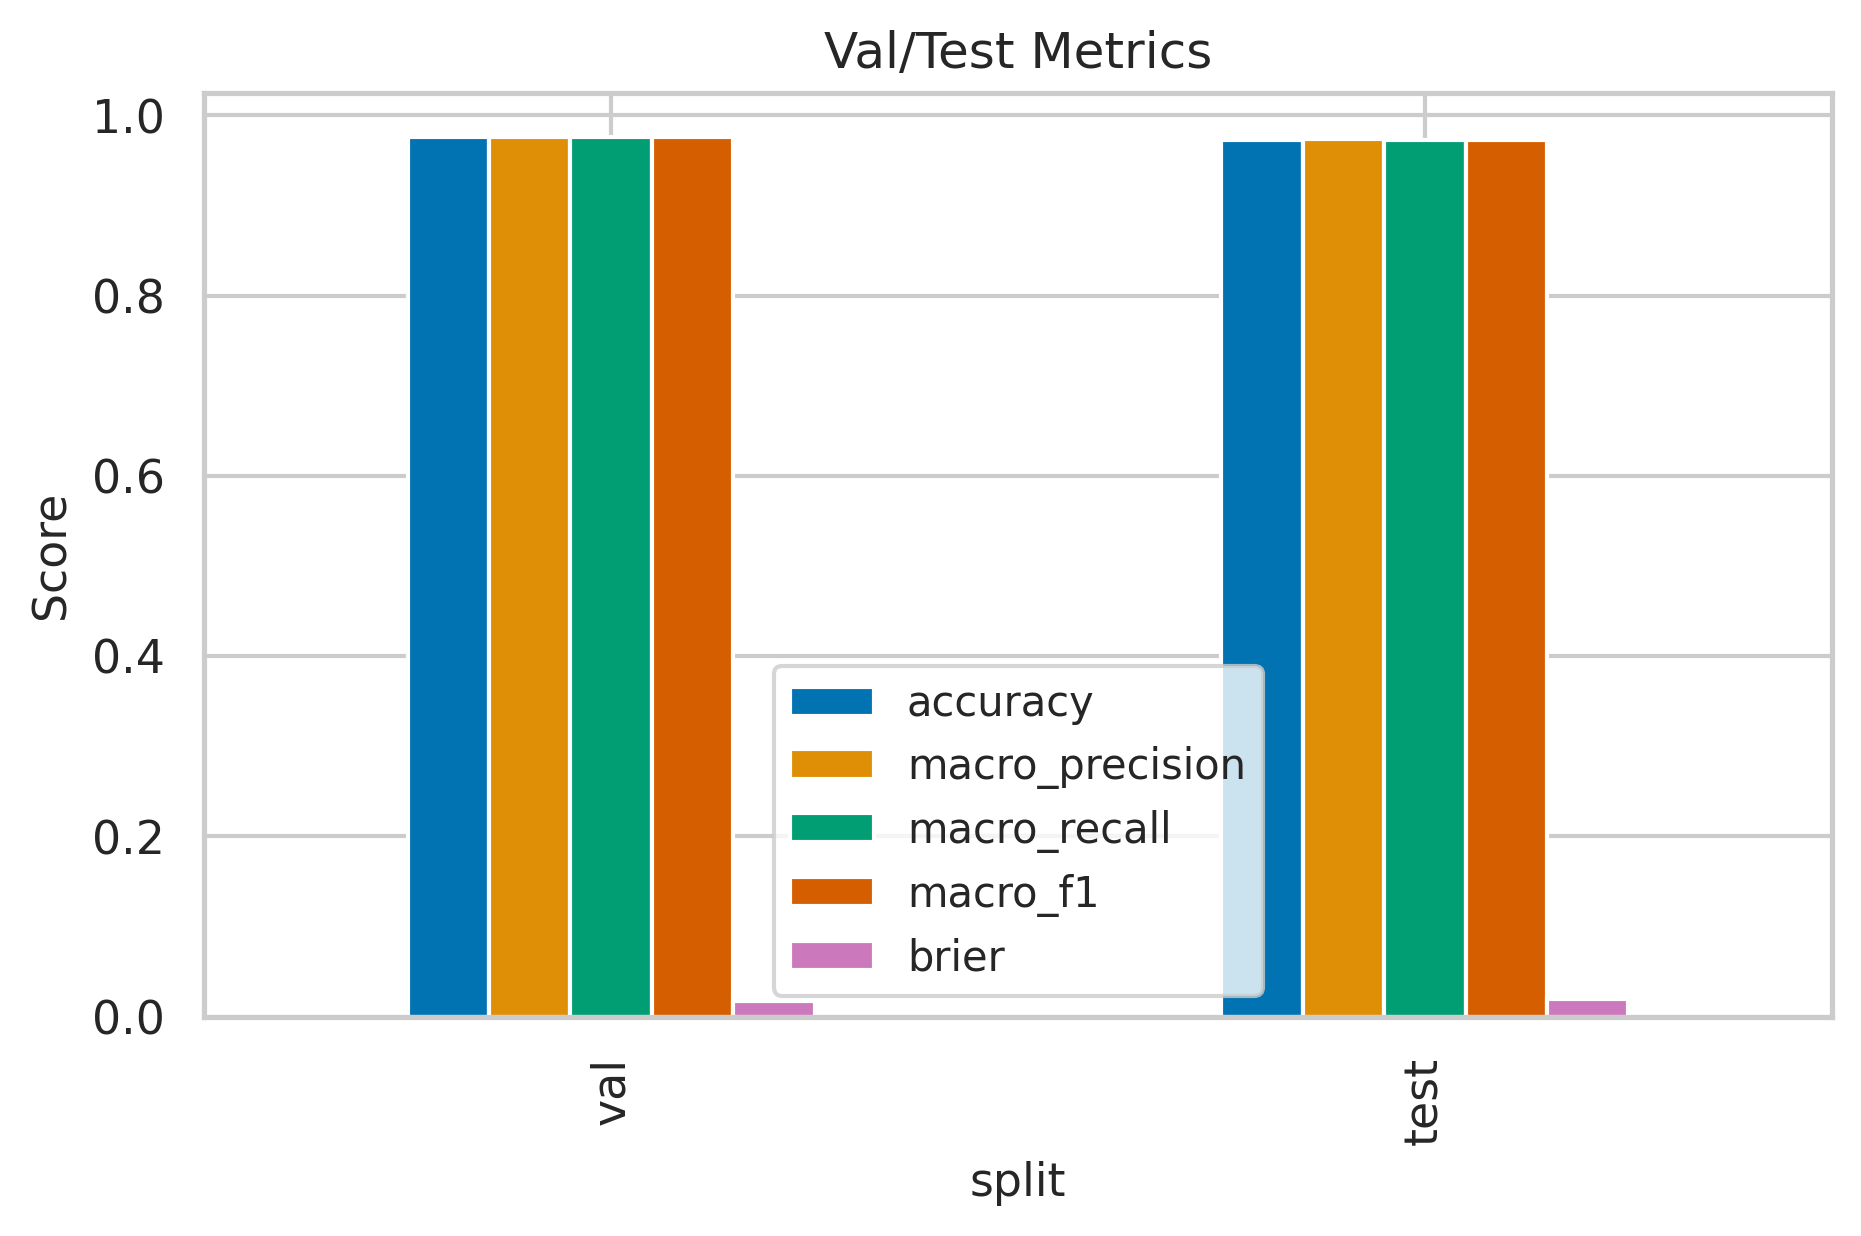

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Reliability on validation
bin_conf, bin_acc, bin_count = reliability_bins(
    val_outputs["probs"], val_outputs["labels"].cpu().numpy(), n_bins=trainer.cfg.reliability_bins
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.bar(bin_conf, bin_acc, width=1.0 / trainer.cfg.reliability_bins, alpha=0.6, align="center")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title(f"Validation Reliability | ECE={val_metrics['ece']:.3f}")
ax.legend()
save_fig(fig, "reliability_val", prefix="evaluate")
plt.show()

# Reliability on test
bin_conf_t, bin_acc_t, bin_count_t = reliability_bins(
    test_outputs["probs"], test_outputs["labels"].cpu().numpy(), n_bins=trainer.cfg.reliability_bins
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.bar(bin_conf_t, bin_acc_t, width=1.0 / trainer.cfg.reliability_bins, alpha=0.6, align="center")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title(f"Test Reliability | ECE={test_metrics['ece']:.3f}")
ax.legend()
save_fig(fig, "reliability_test", prefix="evaluate")
plt.show()

# Confusion matrices
class_names = trainer.datamodule.train_dataset.classes
for split_name, outputs in [("val", val_outputs), ("test", test_outputs)]:
    probs = outputs["probs"]
    labels = outputs["labels"].cpu().numpy()
    preds = probs.argmax(axis=1)
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{split_name.capitalize()} Confusion Matrix")
    save_fig(fig, f"confusion_{split_name}", prefix="evaluate")
    plt.show()

# Score histograms (positive class) for val/test
for split_name, outputs in [("val", val_outputs), ("test", test_outputs)]:
    probs = outputs["probs"]
    labels = outputs["labels"].cpu().numpy()
    pos_scores = probs[:, 1] if probs.shape[1] > 1 else probs[:, 0]
    fig, ax = plt.subplots(figsize=(6, 4))
    for label_val, label_name in enumerate(class_names):
        ax.hist(pos_scores[labels == label_val], bins=20, alpha=0.6, label=label_name)
    ax.set_xlabel("Predicted probability (class 1)")
    ax.set_ylabel("Count")
    ax.set_title(f"{split_name.capitalize()} Score Histogram")
    ax.legend()
    save_fig(fig, f"score_hist_{split_name}", prefix="evaluate")
    plt.show()

# Metric summary bar chart
summary_df = pd.DataFrame([
    {"split": "val", **val_metrics},
    {"split": "test", **test_metrics},
]).set_index("split")
fig, ax = plt.subplots(figsize=(7, 4))
summary_df[[c for c in summary_df.columns if c != "ece"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Val/Test Metrics")
save_fig(fig, "metrics", prefix="evaluate")
plt.show()
